# GODIP-DO time series plot
- Global and regional time series of O2 inventory
- Global and regional time series of volume-weighted O2
- Calculating linear trend

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd

In [ ]:
# open the dataset
ds=xr.open_dataset('GODIP-DO_NCEI_67C0_Aug2025.nc')

In [ ]:
# pre-compute the k-index for vertical, 100m, 300m, 600m, 700m, 1000m
time=ds.time.to_numpy()
zstd=ds.depth.to_numpy()
Nz=np.size(zstd)
z=np.zeros(Nz+1)
z[1:]=zstd
#
K10=np.argmin(np.abs(z-1000))
K7=np.argmin(np.abs(z-700))
K6=np.argmin(np.abs(z-600))
K3=np.argmin(np.abs(z-300))
K1=np.argmin(np.abs(z-100))
#
# make sure it's working for python indexing
print(zstd[K1-1],zstd[K3-1],zstd[K6-1],zstd[K7-1],zstd[K10-1])

100.0 300.0 600.0 700.0 1000.0


In [ ]:
# get the coordinates in numpy array
x= ds.lon.to_numpy()
y=ds.lat.to_numpy()
z=ds.depth.to_numpy()
time=ds.time.to_numpy()
prod=np.array(['IAP','GT-OI','UTAS','SJTU-GR','UW','GT-ML','SJTU-JW','SJTU-HZ'],dtype='U8')

/glade/derecho/scratch/ito/tmp/ipykernel_27750/3848826966.py:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(x,y,bdemo[0,:,:])


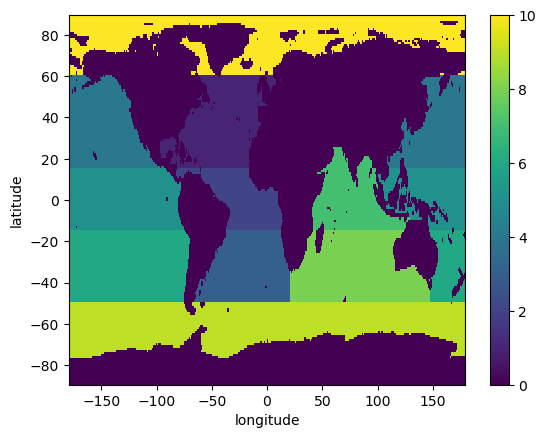

In [ ]:
# define the names of the ocean basins
bn=['Global','North Atlantic','Eq. Atlantic','South Atlantic',
    'North Pacific','Eq. Pacific','South Pacific','Eq. Indian',
    'South Indian','Southern Ocean','Arctic']
#
# visualize the ocean basins
bdemo=ds.basin_id.to_numpy()
plt.pcolormesh(x,y,bdemo[0,:,:])
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar()
#plt.savefig('basin_defs.pdf',bbox_inches='tight')

In [ ]:
# get the entire o2 dataset as the numpy array (hope you have enough memory)
o21 = ds.o2anom.to_numpy()

In [ ]:
# Calculate the O2 inventory/volume-weighted mean concentration for 0-1000m
#
Nt=np.size(ds.time)
oave=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
# note: 11 region = 1 global + 10 basins
oinv=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
#
for k in range(Nt): # loop over time
    for n in range(11): # loop over regions
        dv=ds.dv.to_numpy()
        if n==0:
            bw=np.where(bdemo==0,0,dv) # global (not land)
        else:
            bw=np.where(bdemo==n,dv,0) # regional mask
        #
        for m in range(8): # loop over datasets
            tmp = np.nansum(o21[m,k,:K10,:,:]*bw[:K10,:,:]) # volume integration of O2 anom
            tmp0= np.nansum(bw[:K10,:,:]) # volume integration of 1 = volume
            oinv[n,m,k]=tmp # inventory
            oave[n,m,k]=tmp/tmp0 # volume-weighted mean concentration

In [ ]:
# Calculate the O2 inventory/volume-weighted mean concentration for 0-100m
#
Nt=np.size(ds.time)
oave1=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
# note: 11 region = 1 global + 10 basins
oinv1=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
#
for k in range(Nt): # loop over time
    for n in range(11): # loop over regions
        dv=ds.dv.to_numpy()
        if n==0:
            bw=np.where(bdemo==0,0,dv) # global (not land)
        else:
            bw=np.where(bdemo==n,dv,0) # regional mask
        #
        for m in range(8): # loop over datasets
            tmp = np.nansum(o21[m,k,:K1,:,:]*bw[:K1,:,:]) # volume integration of O2 anom
            tmp0= np.nansum(bw[:K1,:,:]) # volume integration of 1 = volume
            oinv1[n,m,k]=tmp # inventory
            oave1[n,m,k]=tmp/tmp0 # volume-weighted mean concentration

In [ ]:
# Calculate the O2 inventory/volume-weighted mean concentration for 100-600m
#
Nt=np.size(ds.time)
oave16=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
# note: 11 region = 1 global + 10 basins
oinv16=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
#
for k in range(Nt): # loop over time
    for n in range(11): # loop over regions
        dv=ds.dv.to_numpy()
        if n==0:
            bw=np.where(bdemo==0,0,dv) # global (not land)
        else:
            bw=np.where(bdemo==n,dv,0) # regional mask
        #
        for m in range(8): # loop over datasets
            tmp = np.nansum(o21[m,k,K1:K6,:,:]*bw[K1:K6,:,:]) # volume integration of O2 anom
            tmp0= np.nansum(bw[K1:K6,:,:]) # volume integration of 1 = volume
            oinv16[n,m,k]=tmp # inventory
            oave16[n,m,k]=tmp/tmp0 # volume-weighted mean concentration

In [ ]:
# Calculate the O2 inventory/volume-weighted mean concentration for 600m-1000m
#
Nt=np.size(ds.time)
oave610=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
# note: 11 region = 1 global + 10 basins
oinv610=np.zeros((11,8,Nt)) # (11 regions, 8 datasets, time steps)
#
for k in range(Nt): # loop over time
    for n in range(11): # loop over regions
        dv=ds.dv.to_numpy()
        if n==0:
            bw=np.where(bdemo==0,0,dv) # global (not land)
        else:
            bw=np.where(bdemo==n,dv,0) # regional mask
        #
        for m in range(8): # loop over datasets
            tmp = np.nansum(o21[m,k,K6:K10,:,:]*bw[K6:K10,:,:]) # volume integration of O2 anom
            tmp0= np.nansum(bw[K6:K10,:,:]) # volume integration of 1 = volume
            oinv610[n,m,k]=tmp # inventory
            oave610[n,m,k]=tmp/tmp0 # volume-weighted mean concentration

In [ ]:
# plotting!!!

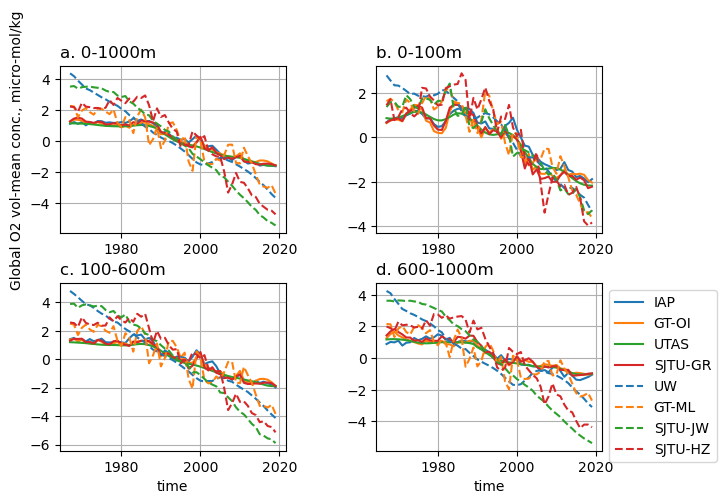

In [ ]:
fig=plt.figure(figsize=(7,5))
ax=fig.subplots(2,2)
cm1=plt.get_cmap('tab10')
cm2=plt.get_cmap('tab10')
time=np.arange(1967,2021,1)
plt.subplots_adjust(wspace=.4,hspace=.3)
##########################################
# global : n=0
# change the value of n for other basins
n=0
##########################################
for m in range(8):
    if m<=3:
        ax[0,0].plot(time[:-1],oave[n,m,:-1],'-',color=cm1(m),label=f'{prod[m]}')
        ax[0,1].plot(time[:-1],oave1[n,m,:-1],'-',color=cm1(m),label=f'{prod[m]}')
        ax[1,0].plot(time[:-1],oave16[n,m,:-1],'-',color=cm1(m),label=f'{prod[m]}')
        ax[1,1].plot(time[:-1],oave610[n,m,:-1],'-',color=cm1(m),label=f'{prod[m]}')
    else:
        ax[0,0].plot(time[:-1],oave[n,m,:-1],'--',color=cm1(m-4),label=f'{prod[m]}')
        ax[0,1].plot(time[:-1],oave1[n,m,:-1],'--',color=cm1(m-4),label=f'{prod[m]}')
        ax[1,0].plot(time[:-1],oave16[n,m,:-1],'--',color=cm1(m-4),label=f'{prod[m]}')
        ax[1,1].plot(time[:-1],oave610[n,m,:-1],'--',color=cm1(m-4),label=f'{prod[m]}')

#
ax[0,0].set_ylabel(f'{bn[n]} O2 vol-mean conc., micro-mol/kg')
#
tit=np.array([['a. 0-1000m','b. 0-100m'],['c. 100-600m','d. 600-1000m']])
#print(tit)
ax[1,1].legend(bbox_to_anchor=(1,1),fontsize=10)
for m in range(2):
    ax[1,m].set_xlabel('time')
    for n in range(2):
        ax[n,m].grid()
        ax[n,m].set_title(tit[n,m],loc='left')
#
#plt.savefig(f'o2_volmean_{bn[n]}-all.pdf',bbox_inches='tight')

Text(0.5, 0, 'time')

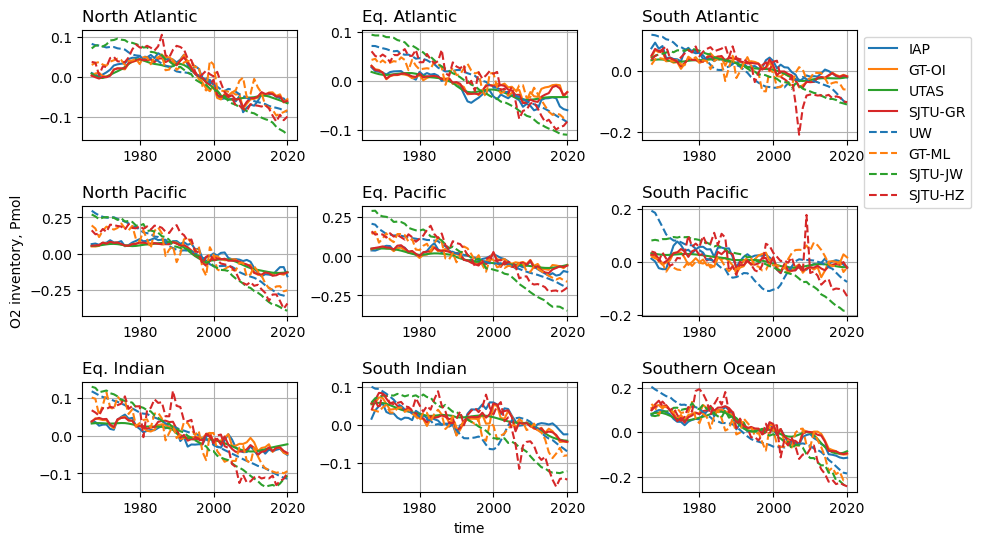

In [ ]:
# basin-wise trend
#  - plots 9 major basins (excluding Global and Arctic for space)
#
#  - for inventory, convert the units from micro-mol/kg.m3 to Pmol. To do so, multiply by 1025e-21
data = oinv*1025e-21
#
fig=plt.figure(figsize=(10,6))
ax=fig.subplots(3,3)
ax=ax.flatten()
plt.subplots_adjust(hspace=.6,wspace=.3)
#
for n in range(9):
    for m in range(8):
        if m<=3: # non-ML datasets (solid line)
            ax[n].plot(time,data[n+1,m,:],'-',color=cm1(m),label=f'{prod[m]}')
        else: # ML-based datasets (dash line)
            ax[n].plot(time,data[n+1,m,:],'--',color=cm2(m-4),label=f'{prod[m]}')
    ax[n].set_title(f'{bn[n+1]}',loc='left')
    if n==2:
        ax[n].legend(bbox_to_anchor=(1,1))
    ax[n].grid()
#
ax[3].set_ylabel('O2 inventory, Pmol')
ax[7].set_xlabel('time')
#plt.savefig('o2_inv_basin_0-1000m-all.pdf',bbox_inches='tight')

In [ ]:
# calculating linear trend for each region
o2tr=np.zeros((8,11,2))
o2tr1=np.zeros((8,11,2))
o2tr16=np.zeros((8,11,2))
o2tr610=np.zeros((8,11,2))
#
for n in range(11): # for each region
    for m in range(8): # for each dataset
        c=np.cov(time,oave[n,m,:])
        o2tr[m,n,0]=c[0,1]/c[0,0]*10
        c=np.cov(time,oinv[n,m,:]*1025e-21)
        o2tr[m,n,1]=c[0,1]/c[0,0]*10
        #
        c=np.cov(time,oave1[n,m,:])
        o2tr1[m,n,0]=c[0,1]/c[0,0]*10
        c=np.cov(time,oinv1[n,m,:]*1025e-21)
        o2tr1[m,n,1]=c[0,1]/c[0,0]*10
        #
        c=np.cov(time,oave16[n,m,:])
        o2tr16[m,n,0]=c[0,1]/c[0,0]*10
        c=np.cov(time,oinv16[n,m,:]*1025e-21)
        o2tr16[m,n,1]=c[0,1]/c[0,0]*10
        #
        c=np.cov(time,oave610[n,m,:])
        o2tr610[m,n,0]=c[0,1]/c[0,0]*10
        c=np.cov(time,oinv610[n,m,:]*1025e-21)
        o2tr610[m,n,1]=c[0,1]/c[0,0]*10

Text(0, 0.5, 'O2 inventory change, 2010s - 2070s, PmolO2')

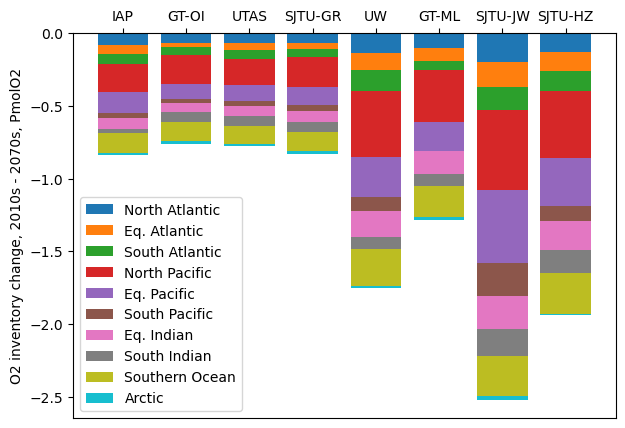

In [ ]:
# display the bar chart
#
# trend comparison # 2010s minus 1970s
#
fig=plt.figure(figsize=(7,5))
ax=fig.subplots(1,1)
#
ind0 = (time >= 1970) & (time<=1979)
ind1 = (time >= 2010) & (time<=2019)
dtr = np.mean(oinv[:,:,ind1],axis=2) - np.mean(oinv[:,:,ind0],axis=2)
dtr = dtr*1025e-21
base=np.zeros(8)
#
for n in range(10):
    if n==0:
        bot=base
    else:
        bot=bot+dtr[n,:]
    #
    ax.bar(prod,dtr[n+1,:],bottom=bot,label=bn[n+1],color=cm1(n))
#
ax.legend()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_ylabel('O2 inventory change, 2010s - 2070s, PmolO2')
#plt.savefig('trend_comparison-0-1000m-all.pdf',bbox_inches='tight')

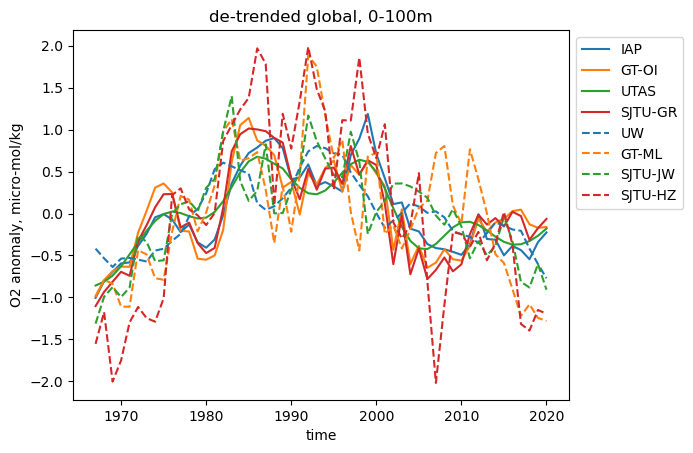

In [ ]:
# de-trended interannual variability
#
from scipy.signal import detrend
#
n=0
for m in range(4):
    plt.plot(time,detrend(oave1[n,m,:]),'-',color=cm1(m),label=prod[m])
for m in range(4):
    plt.plot(time,detrend(oave1[n,m+4,:]),'--',color=cm1(m),label=prod[m+4])
plt.legend()
plt.title('de-trended global, 0-100m')
plt.xlabel('time')
plt.ylabel('O2 anomaly, micro-mol/kg')
plt.legend(bbox_to_anchor=(1,1))
# plt.savefig('detrended-global_0-100m_all.pdf',bbox_inches='tight')

Text(0.5, 1.0, 'Global correlation, 0-100m')

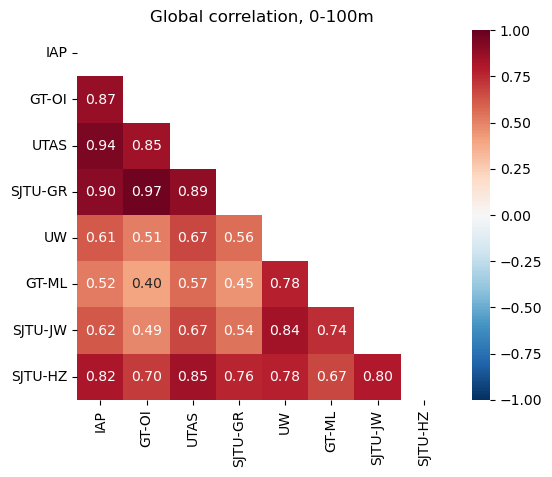

In [ ]:
# correlation table
from scipy.signal import detrend
import seaborn as sns
#
n=0 # global
#
df = pd.DataFrame(data = np.squeeze(detrend(oave1[n,:,:],axis=1)).T,columns=prod,index=time)
rmat0 = df.corr(method='pearson').round(2)
#rmat1 = df.corr(method='spearman').round(2)
mask = np.triu(np.ones_like(rmat0,dtype=bool))
sns.heatmap(rmat0, vmin=-1, vmax=1, cmap='RdBu_r',annot=True,square=True,fmt='0.2f',mask=mask)
plt.title(f'{bn[n]} correlation, 0-100m')

In [ ]:
# spatial pattern of the trend, 0-1000m integral
dh=ds.dh.to_numpy()
time=np.arange(1967,2021,1)
o2trmap=np.zeros((8,180,360))
for n in range(8):
    tmp = np.sum(o21[n,:,:K10,:,:] * dh[:K10,:,:], axis=1)*1025e-6
    for i in range(360):
        for j in range(180):
            X = time
            Y = tmp[:,j,i]
            c = np.cov(X,Y)
            o2trmap[n,j,i]=c[0,1]/c[0,0]*10 # o2 mol/m2/decade trend

/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1

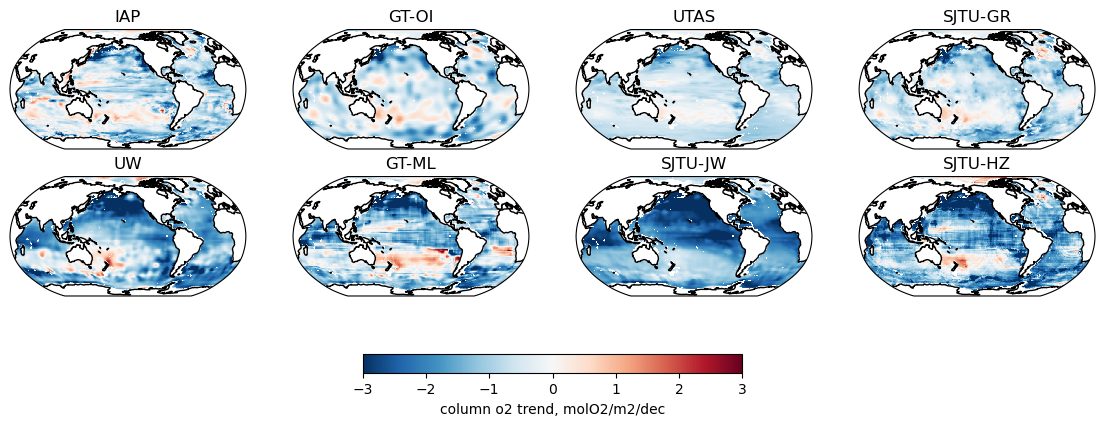

In [ ]:
fig=plt.figure(figsize=(14,5))
x1=np.arange(0.5,361,1)
x1[-1]=0.5
ax=fig.subplots(2,4,subplot_kw={'projection':ccrs.Robinson(central_longitude=-150)})
ax=ax.flatten()
for n in range(8):
    im=ax[n].pcolormesh(x1-180,y,o2trmap[n,:,:],cmap='RdBu_r',vmin=-3,vmax=3,transform=ccrs.PlateCarree(),rasterized=True)
    ax[n].coastlines()
    ax[n].set_title(prod[n])
plt.colorbar(im,ax=ax[:],shrink=.35,label='column o2 trend, molO2/m2/dec',location='bottom')
#plt.savefig(f'trend_0-1000m-all.pdf',bbox_inches='tight')

In [ ]:
# spatial pattern of the trend, 0-100m integral
dh=ds.dh.to_numpy()
time=np.arange(1967,2021,1)
o2trmap=np.zeros((8,180,360))
for n in range(8):
    tmp = np.sum(o21[n,:,:K1,:,:] * dh[:K1,:,:], axis=1)*1025e-6
    for i in range(360):
        for j in range(180):
            X = time
            Y = tmp[:,j,i]
            c = np.cov(X,Y)
            o2trmap[n,j,i]=c[0,1]/c[0,0]*10 # o2 mol/m2/decade trend

/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1

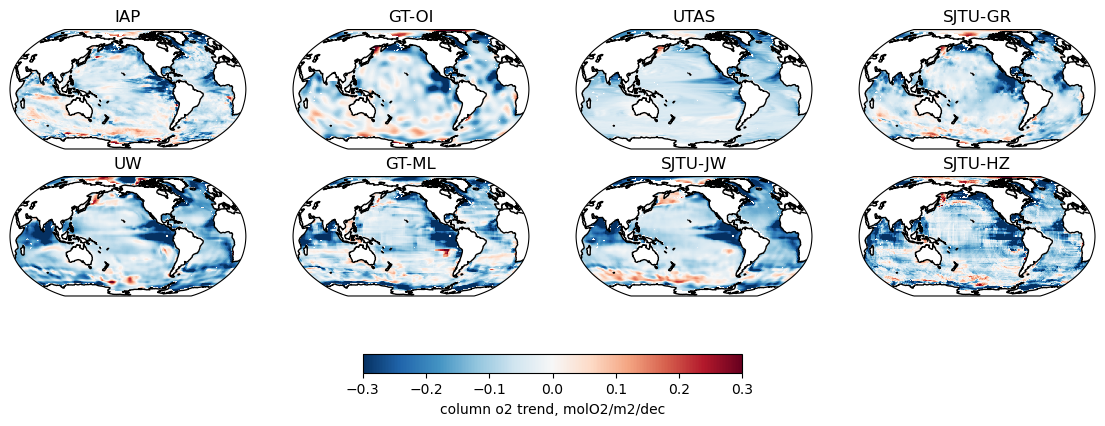

In [ ]:
fig=plt.figure(figsize=(14,5))
x1=np.arange(0.5,361,1)
x1[-1]=0.5
ax=fig.subplots(2,4,subplot_kw={'projection':ccrs.Robinson(central_longitude=-150)})
ax=ax.flatten()
for n in range(8):
    im=ax[n].pcolormesh(x1-180,y,o2trmap[n,:,:],cmap='RdBu_r',vmin=-.3,vmax=.3,transform=ccrs.PlateCarree(),rasterized=True)
    ax[n].coastlines()
    ax[n].set_title(prod[n])
plt.colorbar(im,ax=ax[:],shrink=.35,label='column o2 trend, molO2/m2/dec',location='bottom')
#plt.savefig(f'trend_0-100m-all.pdf',bbox_inches='tight')

In [ ]:
# spatial pattern of the trend, 100-600m integral
dh=ds.dh.to_numpy()
time=np.arange(1967,2021,1)
o2trmap=np.zeros((8,180,360))
for n in range(8):
    tmp = np.sum(o21[n,:,K1:K6,:,:] * dh[K1:K6,:,:], axis=1)*1025e-6
    for i in range(360):
        for j in range(180):
            X = time
            Y = tmp[:,j,i]
            c = np.cov(X,Y)
            o2trmap[n,j,i]=c[0,1]/c[0,0]*10 # o2 mol/m2/decade trend

/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1

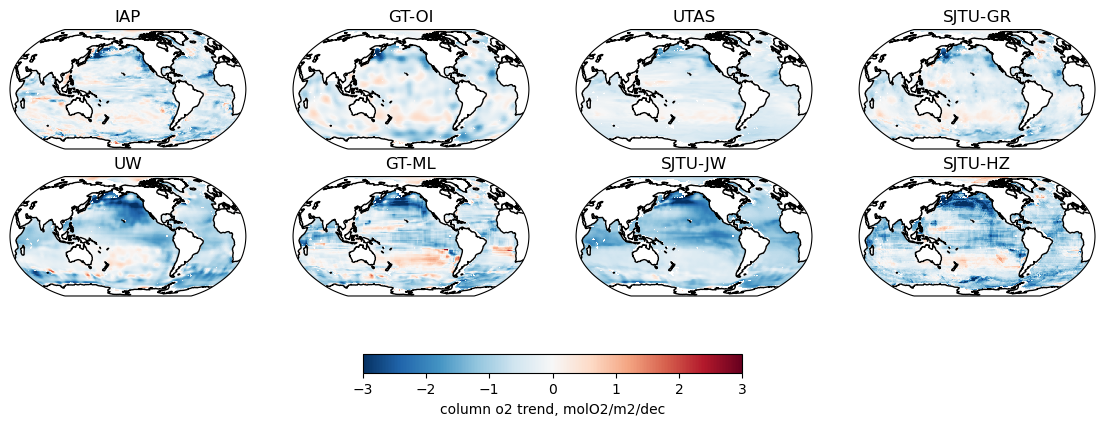

In [ ]:
fig=plt.figure(figsize=(14,5))
x1=np.arange(0.5,361,1)
x1[-1]=0.5
ax=fig.subplots(2,4,subplot_kw={'projection':ccrs.Robinson(central_longitude=-150)})
ax=ax.flatten()
for n in range(8):
    im=ax[n].pcolormesh(x1-180,y,o2trmap[n,:,:],cmap='RdBu_r',vmin=-3,vmax=3,transform=ccrs.PlateCarree(),rasterized=True)
    ax[n].coastlines()
    ax[n].set_title(prod[n])
plt.colorbar(im,ax=ax[:],shrink=.35,label='column o2 trend, molO2/m2/dec',location='bottom')
#plt.savefig(f'trend_100-600m-all.pdf',bbox_inches='tight')

In [ ]:
# spatial pattern of the trend, 600-1000m integral
dh=ds.dh.to_numpy()
time=np.arange(1967,2021,1)
o2trmap=np.zeros((8,180,360))
for n in range(8):
    tmp = np.sum(o21[n,:,K6:K10,:,:] * dh[K6:K10,:,:], axis=1)*1025e-6
    for i in range(360):
        for j in range(180):
            X = time
            Y = tmp[:,j,i]
            c = np.cov(X,Y)
            o2trmap[n,j,i]=c[0,1]/c[0,0]*10 # o2 mol/m2/decade trend

/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1785: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = super().pcolormesh(*args, **kwargs)
/glade/work/ito/miniconda3/envs/calc2/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1

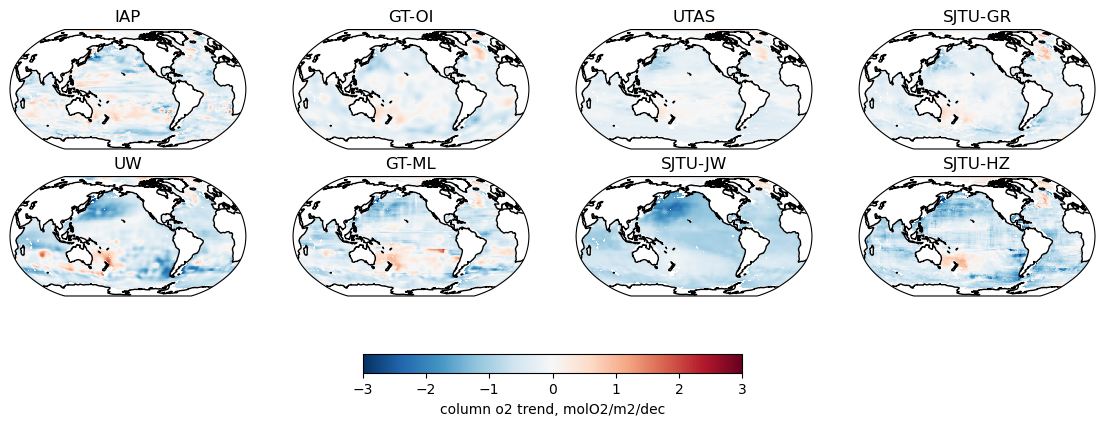

In [ ]:
fig=plt.figure(figsize=(14,5))
x1=np.arange(0.5,361,1)
x1[-1]=0.5
ax=fig.subplots(2,4,subplot_kw={'projection':ccrs.Robinson(central_longitude=-150)})
ax=ax.flatten()
for n in range(8):
    im=ax[n].pcolormesh(x1-180,y,o2trmap[n,:,:],cmap='RdBu_r',vmin=-3,vmax=3,transform=ccrs.PlateCarree(),rasterized=True)
    ax[n].coastlines()
    ax[n].set_title(prod[n])
plt.colorbar(im,ax=ax[:],shrink=.35,label='column o2 trend, molO2/m2/dec',location='bottom')
#plt.savefig(f'trend_600-1000m-all.pdf',bbox_inches='tight')